In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_wout_costs = pd.read_csv('../outputs/grid_search_results.csv')
df_with_costs = pd.read_csv('../outputs/grid_search_results_with_costs.csv')

## Sigma Prior

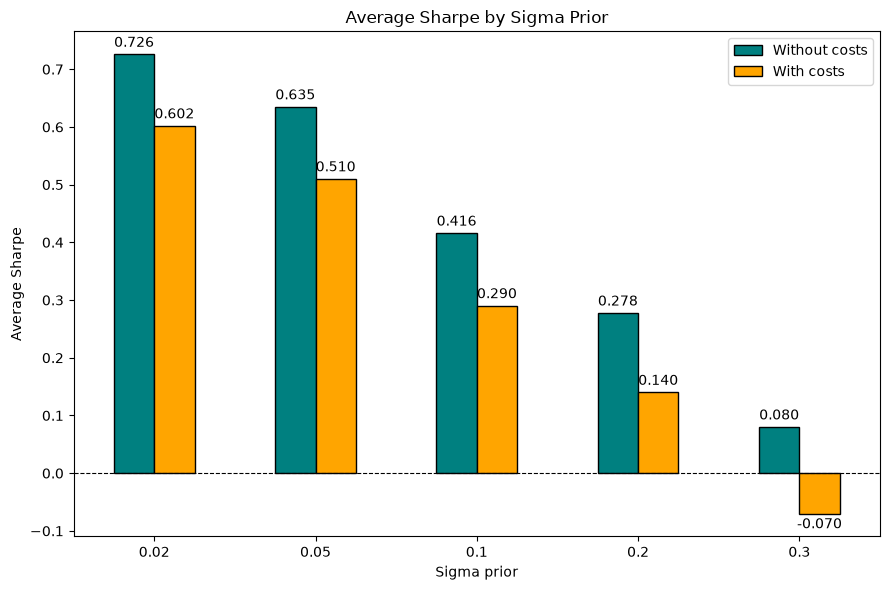

In [3]:
# Calculate average Sharpe ratios by sigma_prior
avg_sharpe_sigma = pd.DataFrame({
    "Without costs": df_wout_costs.groupby("sigma_prior")["sharpe"].mean(),
    "With costs": df_with_costs.groupby("sigma_prior")["sharpe"].mean(),
}).sort_index()

# Create stacked column chart
ax = avg_sharpe_sigma.plot(
    kind="bar",
    stacked=False,
    figsize=(9, 6),
    color=['teal', 'orange'],
    edgecolor="black"
)

ax.set_xlabel("Sigma prior")
ax.set_ylabel("Average Sharpe")
ax.set_title("Average Sharpe by Sigma Prior")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)

# Add labels to all bar containers
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig('avg_sharpe_by_sigma_prior.png', dpi=300)
plt.show()

## Drift Horizon

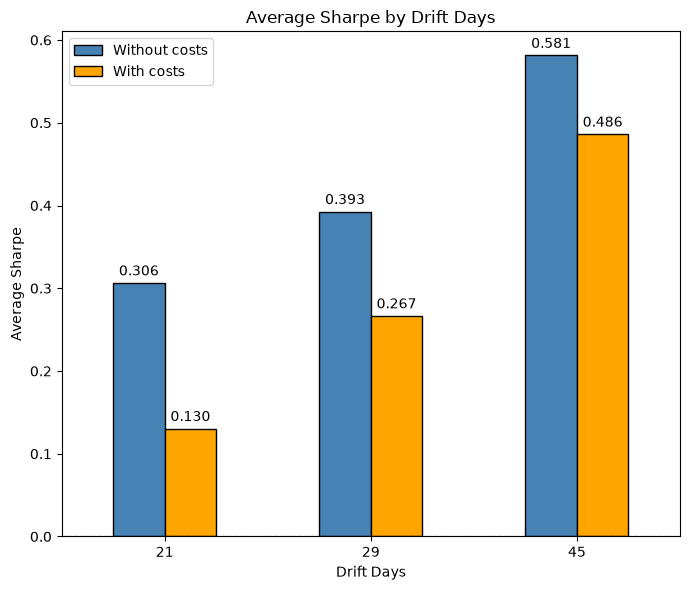

In [4]:
# Calculate average Sharpe ratios by drift_days
avg_sharpe_drift = pd.DataFrame({
    "Without costs": df_wout_costs.groupby("drift_days")["sharpe"].mean(),
    "With costs": df_with_costs.groupby("drift_days")["sharpe"].mean(),
}).sort_index()

# Create stacked column chart
ax = avg_sharpe_drift.plot(
    kind="bar",
    stacked=False,
    figsize=(7, 6),
    color=['steelblue', 'orange'],
    edgecolor="black"
)

ax.set_xlabel("Drift Days")
ax.set_ylabel("Average Sharpe")
ax.set_title("Average Sharpe by Drift Days")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)

# Add labels to all bar containers
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig('avg_sharpe_by_drift_days.png', dpi=300)
plt.show()

## Signal Weight

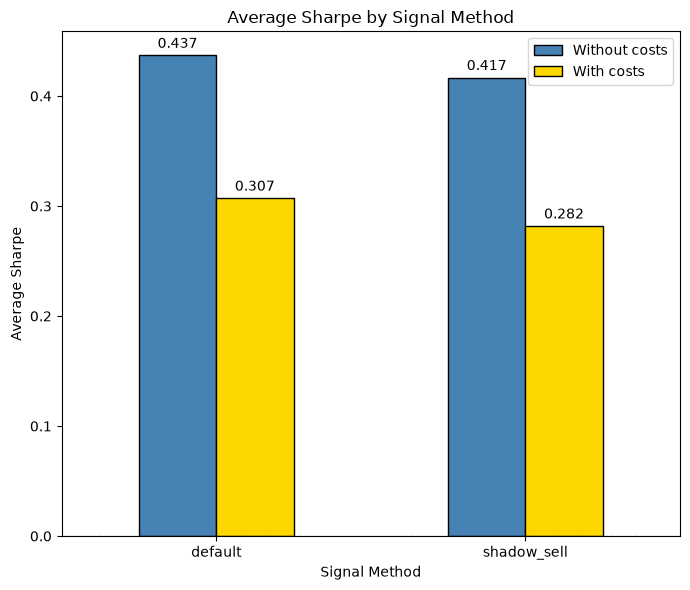

In [5]:
avg_sharpe_signal = pd.DataFrame({
    "Without costs": df_wout_costs.groupby("signal_method")["sharpe"].mean(),
    "With costs": df_with_costs.groupby("signal_method")["sharpe"].mean(),
}).sort_index()

# Create stacked column chart
ax = avg_sharpe_signal.plot(
    kind="bar",
    stacked=False,
    figsize=(7, 6),
    color=['steelblue', 'gold'],
    edgecolor="black"
)

ax.set_xlabel("Signal Method")
ax.set_ylabel("Average Sharpe")
ax.set_title("Average Sharpe by Signal Method")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)

# Add labels to all bar containers
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig('avg_sharpe_by_signal_method.png', dpi=300)
plt.show()

## Position Sizing

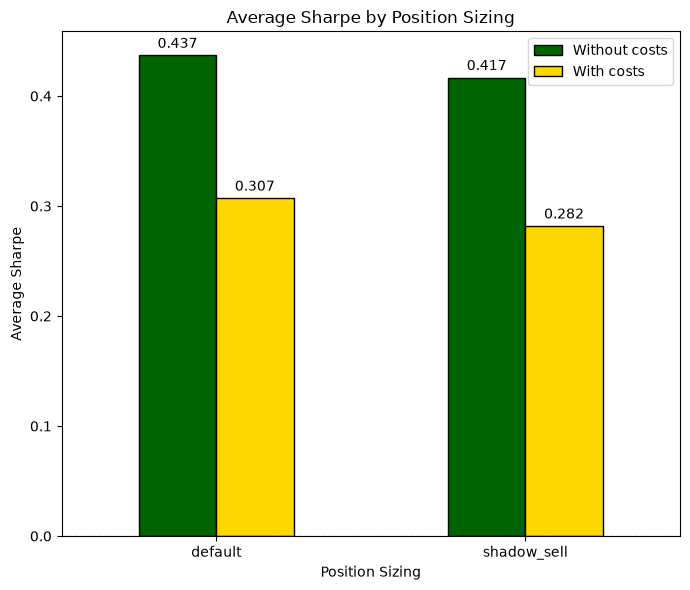

In [6]:
avg_sharpe_ps = pd.DataFrame({
    "Without costs": df_wout_costs.groupby("position_sizing")["sharpe"].mean(),
    "With costs": df_with_costs.groupby("position_sizing")["sharpe"].mean(),
}).sort_index()

# Create stacked column chart
ax = avg_sharpe_signal.plot(
    kind="bar",
    stacked=False,
    figsize=(7, 6),
    color=['darkgreen', 'gold'],
    edgecolor="black"
)

ax.set_xlabel("Position Sizing")
ax.set_ylabel("Average Sharpe")
ax.set_title("Average Sharpe by Position Sizing")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)

# Add labels to all bar containers
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig('avg_sharpe_by_position_sizing.png', dpi=300)
plt.show()

## Effect of transaction costs

In [7]:
# Compare overall average Sharpe ratio and annualized return
avg_metrics = pd.DataFrame({
    "Without costs": [
        df_wout_costs["sharpe"].mean(),
        df_wout_costs["ann_return"].mean(),
        df_wout_costs["max_drawdown"].mean()
    ],
    "With costs": [
        df_with_costs["sharpe"].mean(),
        df_with_costs["ann_return"].mean(),
        df_with_costs["max_drawdown"].mean()
    ]
}, index=["Average Sharpe", "Average Annual Return", "Average Max Drawdown"])

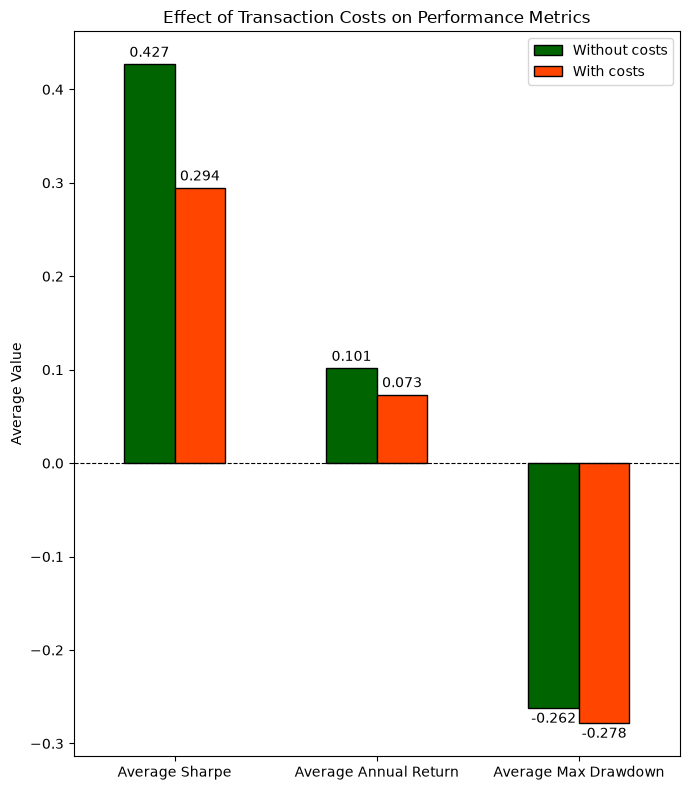

In [8]:
ax = avg_metrics.plot(
    kind="bar",
    figsize=(7, 8),
    color=["darkgreen", "orangered"],
    edgecolor="black"
)

ax.set_title("Effect of Transaction Costs on Performance Metrics")
ax.set_ylabel("Average Value")
ax.set_xlabel("")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig('transaction_costs_on_performance_metrics.png', dpi=300)
plt.show()

## Market Exposure

### Alpha

In [9]:
avg_metrics_alpha = pd.DataFrame({
    "Without costs": [
        df_wout_costs["ann_alpha"].mean(),
        df_wout_costs["alpha_t"].mean(),
        df_wout_costs["alpha_p"].mean()
    ],
    "With costs": [
        df_with_costs["ann_alpha"].mean(),
        df_with_costs["alpha_t"].mean(),
        df_with_costs["alpha_p"].mean()
    ]
}, index=["Avg annualized alpha", "Avg alpha_t", "Avg alpha_p"])

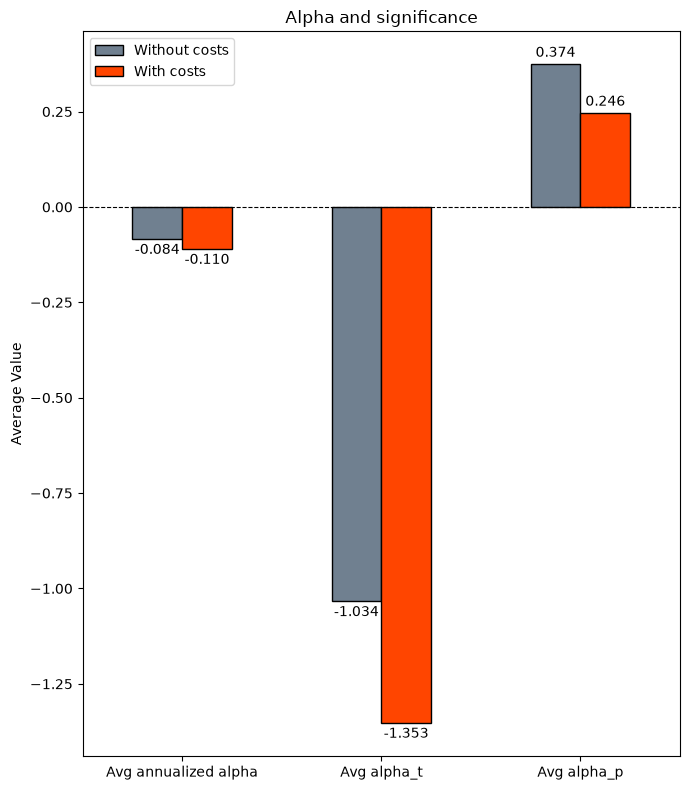

In [10]:
ax = avg_metrics_alpha.plot(
    kind="bar",
    figsize=(7, 8),
    color=["slategray", "orangered"],
    edgecolor="black"
)

ax.set_title("Alpha and significance")
ax.set_ylabel("Average Value")
ax.set_xlabel("")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig('alpha_and_significance.png', dpi=300)
plt.show()

### Beta

In [11]:
mean_beta = df_wout_costs["beta"].mean()
mean_beta_with_costs = df_with_costs["beta"].mean()

mean_beta_t = df_wout_costs["beta_t"].mean()
mean_beta_t_with_costs = df_with_costs["beta_t"].mean()

mean_beta_p = df_wout_costs["beta_p"].mean()
mean_beta_p_with_costs = df_with_costs["beta_p"].mean()

print(f"Mean beta without costs: {mean_beta:.4f}")
print(f"Mean beta with costs: {mean_beta_with_costs:.4f}")
print("----------------------------------")
print(f"Mean beta_t without costs: {mean_beta_t:.4f}")
print(f"Mean beta_t with costs: {mean_beta_t_with_costs:.4f}")
print("----------------------------------")
print(f"Mean beta_p without costs: {mean_beta_p:.4f}")
print(f"Mean beta_p with costs: {mean_beta_p_with_costs:.4f}")

Mean beta without costs: 0.6903
Mean beta with costs: 0.6895
----------------------------------
Mean beta_t without costs: 27.9971
Mean beta_t with costs: 27.9539
----------------------------------
Mean beta_p without costs: 0.0000
Mean beta_p with costs: 0.0000
